# USGS dataretrieval Python Package `get_daily()` Examples

This notebook provides examples of using the Python dataretrieval package to retrieve daily streamflow data for a United States Geological Survey (USGS) monitoring location. The dataretrieval package provides a collection of functions to get data from the USGS Water Data API and other online sources of hydrology and water quality data.

### Install the Package

Use the following code to install the package if it doesn't exist already within your Jupyter Python environment.

In [1]:
!pip install dataretrieval

Load the package so you can use it along with other packages used in this notebook.

In [2]:
from IPython.display import display

import dataretrieval.waterdata as waterdata

### Basic Usage

The dataretrieval package has several functions that allow you to retrieve data from different web services. This example uses the `get_daily()` function to retrieve daily streamflow data for a USGS monitoring location from the USGS Water Data API. The following arguments are supported:

Arguments (Additional arguments, if supplied, will be used as query parameters)

* **monitoring_location_id** (string or iterable of strings): A unique identifier representing a single monitoring location, formed by combining the agency code with the site number (e.g. `USGS-10109000`). Accepts a single ID or a list of IDs.
* **parameter_code** (string or iterable of strings): One or more 5-digit USGS parameter codes identifying the constituent measured and its units of measure (e.g. `00060` for discharge).
* **statistic_id** (string or iterable of strings): One or more codes corresponding to the statistic an observation represents (e.g. `00001` for maximum, `00003` for mean).
* **time** (string): The date or interval an observation represents, following RFC 3339. May be a single date, a bounded or half-bounded interval (e.g. `2020-10-01/2021-09-30`), or an ISO 8601 duration (e.g. `P7D` for the past seven days).
* **skip_geometry** (boolean): If `True`, response geometries are omitted and the returned data frame contains no spatial information.

Example 1: Get daily value data for a specific parameter at a single USGS monitoring location between a begin and end date.

In [3]:
# Set the parameters needed to retrieve data
siteNumber = "USGS-10109000"  # LOGAN RIVER ABOVE STATE DAM, NEAR LOGAN, UT
parameterCode = "00060"  # Discharge
startDate = "2020-10-01"
endDate = "2021-09-30"

# Retrieve the data
dailyStreamflow = waterdata.get_daily(
    monitoring_location_id=siteNumber, parameter_code=parameterCode, time=f"{startDate}/{endDate}"
)
print("Retrieved " + str(len(dailyStreamflow[0])) + " data values.")

Retrieving: daily · 1 page · 365 rows


No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/


Retrieved 365 data values.


### Interpreting the Result

The `get_daily()` function returns a tuple containing a pandas data frame and an associated metadata object. The data frame contains the daily values for the observed variable and time period requested. It is a flat table with a default integer index; the dates associated with each observation are held in a `time` column rather than in the index.

Once you've got the data frame, there are several useful things you can do to explore the data.

In [4]:
# Display the data frame as a table
display(dailyStreamflow[0])

,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,daily_id
0,POINT (-111.78398 41.74355),ecae32c6bdbe495abe71288c65b9a1af,USGS-10109000,00060,00003,2020-10-01,88.8,ft^3/s,Approved,None,2025-03-11 21:52:02.820548+00:00,24014492-4f8f-48f1-84aa-fe178eb07209
1,POINT (-111.78398 41.74355),ecae32c6bdbe495abe71288c65b9a1af,USGS-10109000,00060,00003,2020-10-02,90.5,ft^3/s,Approved,None,2025-03-11 21:52:02.820548+00:00,15e8e430-20ce-4802-ae17-850c593be98c
2,POINT (-111.78398 41.74355),ecae32c6bdbe495abe71288c65b9a1af,USGS-10109000,00060,00003,2020-10-03,92.7,ft^3/s,Approved,None,2025-03-11 21:52:02.820548+00:00,73769928-ce1b-4112-a41c-b0d1b1880e34
3,POINT (-111.78398 41.74355),ecae32c6bdbe495abe71288c65b9a1af,USGS-10109000,00060,00003,2020-10-04,91.8,ft^3/s,Approved,None,2025-03-11 21:52:02.820548+00:00,c87a8c53-d9d4-4701-9f13-60b0090cca58
4,POINT (-111.78398 41.74355),ecae32c6bdbe495abe71288c65b9a1af,USGS-10109000,00060,00003,2020-10-05,91.0,ft^3/s,Approved,None,2025-03-11 21:52:02.820548+00:00,b85a8631-ede6-48a7-a17d-ec0cfd8d7ee0
...,...,...,...,...,...,...,...,...,...,...,...,...
360,POINT (-111.78398 41.74355),ecae32c6bdbe495abe71288c65b9a1af,USGS-10109000,00060,00003,2021-09-26,54.2,ft^3/s,Approved,None,2025-03-11 21:52:02.820548+00:00,7f79ca42-11b6-4c34-b13c-23b3d79f4c7a
361,POINT (-111.78398 41.74355),ecae32c6bdbe495abe71288c65b9a1af,USGS-10109000,00060,00003,2021-09-27,54.5,ft^3/s,Approved,None,2025-03-11 21:52:02.820548+00:00,d2ede051-6a50-4e98-b9e8-5fd77cd45ba5
362,POINT (-111.78398 41.74355),ecae32c6bdbe495abe71288c65b9a1af,USGS-10109000,00060,00003,2021-09-28,54.1,ft^3/s,Approved,None,2025-03-11 21:52:02.820548+00:00,fb754ea7-372e-432a-90b6-1cf6ecf990ef
363,POINT (-111.78398 41.74355),ecae32c6bdbe495abe71288c65b9a1af,USGS-10109000,00060,00003,2021-09-29,53.5,ft^3/s,Approved,None,2025-03-11 21:52:02.820548+00:00,1085b93f-da01-4857-9d93-bbd90871c4d2


Show the data types of the columns in the resulting data frame.

In [5]:
print(dailyStreamflow[0].dtypes)

geometry                             geometry
time_series_id                            str
monitoring_location_id                    str
parameter_code                            str
statistic_id                              str
time                           datetime64[us]
value                                 float64
unit_of_measure                           str
approval_status                           str
qualifier                              object
last_modified             datetime64[us, UTC]
daily_id                                  str
dtype: object


Get summary statistics for the daily streamflow values.

In [6]:
dailyStreamflow[0].describe()

,time,value
count,365,365.000000
mean,2021-04-01 00:00:00,95.795616
min,2020-10-01 00:00:00,45.900000
25%,2020-12-31 00:00:00,75.200000
50%,2021-04-01 00:00:00,85.800000
75%,2021-07-01 00:00:00,106.000000
max,2021-09-30 00:00:00,271.000000
std,NaN,41.146872


Make a quick time series plot.

Text(0, 0.5, 'Streamflow (cfs)')

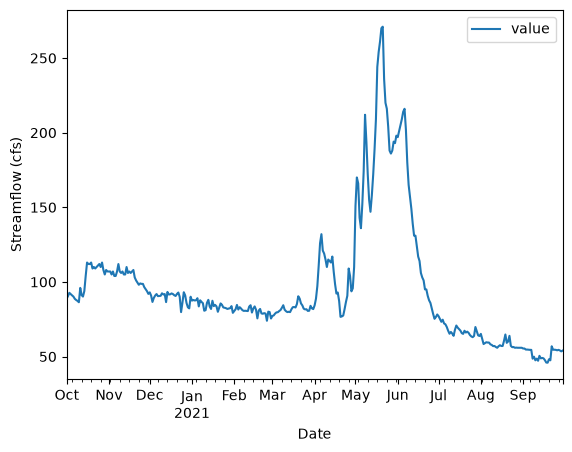

In [7]:
ax = dailyStreamflow[0][["time", "value"]].plot(x="time", y="value")
ax.set_xlabel("Date")
ax.set_ylabel("Streamflow (cfs)")

The other part of the result returned from the `get_daily()` function is a metadata object that contains information about the query that was executed to return the data. For example, you can access the URL that was assembled to retrieve the requested data from the USGS Water Data API.

In [8]:
print(
    "The query URL used to retrieve the data from the Water Data API was: " + dailyStreamflow[1].url
)

The query URL used to retrieve the data from the Water Data API was: https://api.waterdata.usgs.gov/ogcapi/v0/collections/daily/items?monitoring_location_id=USGS-10109000&parameter_code=00060&time=2020-10-01%2F2021-09-30&limit=50000


### Additional Examples

Example 2: Get daily mean and max discharge and temperature values for a monitoring location between a begin and end date.

Parameter Code: 00010 = temperature, 00060 = discharge
See https://help.waterdata.usgs.gov/codes-and-parameters/parameters

Statistic Code: 00001 = Maximum, 00003 = Mean
See https://help.waterdata.usgs.gov/stat_code

NOTE: Temperature and discharge are not fully available for both statistics at this monitoring location.

In [9]:
siteID = "USGS-04085427"
dailyQAndT = waterdata.get_daily(
    monitoring_location_id=siteID,
    parameter_code=["00010", "00060"],
    time=f"{startDate}/{endDate}",
    statistic_id=["00001", "00003"],
)
display(dailyQAndT[0])

Retrieving: daily · 1 page · 883 rows

,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,daily_id
0,POINT (-87.71603 44.10617),66a73e8ca5654ff39e85a0afd29270e9,USGS-04085427,00060,00003,2020-10-01,96.2,ft^3/s,Approved,None,2025-02-28 23:22:14.727748+00:00,8c56a6f4-d1f0-4c80-b909-fabb14f7845d
1,POINT (-87.71603 44.10617),66a73e8ca5654ff39e85a0afd29270e9,USGS-04085427,00060,00003,2020-10-02,90.4,ft^3/s,Approved,None,2025-02-28 23:22:14.727748+00:00,6aa9a4f3-470f-41ed-b190-39605fac58a1
2,POINT (-87.71603 44.10617),66a73e8ca5654ff39e85a0afd29270e9,USGS-04085427,00060,00003,2020-10-03,84.7,ft^3/s,Approved,None,2025-02-28 23:22:14.727748+00:00,490c09f1-84cc-46ff-9a98-eed11438dcdc
3,POINT (-87.71603 44.10617),66a73e8ca5654ff39e85a0afd29270e9,USGS-04085427,00060,00003,2020-10-04,84.9,ft^3/s,Approved,None,2025-02-28 23:22:14.727748+00:00,5f0f2fd6-ae2e-4274-beb6-9e66cfa48638
4,POINT (-87.71603 44.10617),66a73e8ca5654ff39e85a0afd29270e9,USGS-04085427,00060,00003,2020-10-05,93.4,ft^3/s,Approved,None,2025-02-28 23:22:14.727748+00:00,840a86c7-fc3f-4cda-81b9-d71199592c33
...,...,...,...,...,...,...,...,...,...,...,...,...
878,POINT (-87.71603 44.10617),40fb58737a834016aa829aaf5b7852d7,USGS-04085427,00010,00003,2021-09-29,16.2,degC,Approved,None,2025-07-04 09:09:05.251279+00:00,4edbb797-0d48-4bff-9dc1-c87b591be4f0
879,POINT (-87.71603 44.10617),66a73e8ca5654ff39e85a0afd29270e9,USGS-04085427,00060,00003,2021-09-29,96.2,ft^3/s,Approved,None,2025-02-28 23:22:14.727748+00:00,902096d4-0c94-43c2-8915-90b37fcd500e
880,POINT (-87.71603 44.10617),40fb58737a834016aa829aaf5b7852d7,USGS-04085427,00010,00003,2021-09-30,16.9,degC,Approved,None,2025-07-04 09:09:05.251279+00:00,63685ba1-1a37-4bcb-aa8d-b12029790942
881,POINT (-87.71603 44.10617),66a73e8ca5654ff39e85a0afd29270e9,USGS-04085427,00060,00003,2021-09-30,92.9,ft^3/s,Approved,None,2025-02-28 23:22:14.727748+00:00,b4c6d77c-30e6-4aaf-9471-f0f7d08474d4


Example 3: Get daily mean and max discharge and temperature values for multiple monitoring locations between a begin and end date.

In [10]:
dailyMultiSites = waterdata.get_daily(
    monitoring_location_id=["USGS-01491000", "USGS-01645000"],
    parameter_code=["00010", "00060"],
    time="2012-01-01/2012-06-30",
    statistic_id=["00001", "00003"],
)
display(dailyMultiSites[0])

Retrieving: daily · 1 page · 622 rows

,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,daily_id
0,POINT (-75.78581 38.99719),e3e3e89988454bf9b4249a5ec668ebc3,USGS-01491000,00010,00003,2012-01-01,7.70,degC,Approved,None,2025-07-03 21:02:30.201507+00:00,58b9fbe7-a257-4603-956a-ccb0e06f1bdb
1,POINT (-75.78581 38.99719),dd824d8c6ab448af88a9b197048775cc,USGS-01491000,00010,00001,2012-01-01,8.40,degC,Approved,None,2025-07-03 20:40:41.305038+00:00,5c897d0c-4de9-4928-b807-1bc16905d853
2,POINT (-75.78581 38.99719),847d8581ff6c45f58ff7cb90dec31fab,USGS-01491000,00060,00003,2012-01-01,205.00,ft^3/s,Approved,None,2025-03-11 06:37:52.963967+00:00,fda9e856-6cb8-432a-a520-9f682b362bc3
3,POINT (-77.33578 39.12808),890f87c5498e4114b24dc0a53b1adcd8,USGS-01645000,00060,00003,2012-01-01,175.00,ft^3/s,Approved,None,2025-03-10 14:07:21.598533+00:00,ad61ba49-09b5-4156-a6d1-70ff7e4e123b
4,POINT (-75.78581 38.99719),847d8581ff6c45f58ff7cb90dec31fab,USGS-01491000,00060,00003,2012-01-02,193.00,ft^3/s,Approved,None,2025-03-11 06:37:52.963967+00:00,99038716-80c8-41c4-a899-bf8bb555d04e
...,...,...,...,...,...,...,...,...,...,...,...,...
617,POINT (-77.33578 39.12808),890f87c5498e4114b24dc0a53b1adcd8,USGS-01645000,00060,00003,2012-06-28,53.60,ft^3/s,Approved,None,2025-03-10 14:07:21.598533+00:00,2be731ab-1ab9-44e5-b204-4b8565f80a55
618,POINT (-75.78581 38.99719),847d8581ff6c45f58ff7cb90dec31fab,USGS-01491000,00060,00003,2012-06-29,8.58,ft^3/s,Approved,None,2025-03-11 06:37:52.963967+00:00,7f5280e2-91b9-478f-8b97-d849ddbde0c0
619,POINT (-77.33578 39.12808),890f87c5498e4114b24dc0a53b1adcd8,USGS-01645000,00060,00003,2012-06-29,53.10,ft^3/s,Approved,None,2025-03-10 14:07:21.598533+00:00,0c84c8e9-753d-426c-a486-e63b41b895ac
620,POINT (-75.78581 38.99719),847d8581ff6c45f58ff7cb90dec31fab,USGS-01491000,00060,00003,2012-06-30,7.15,ft^3/s,Approved,None,2025-03-11 06:37:52.963967+00:00,0ba8a05a-e951-4179-9838-34fca388346c


Like all of the `waterdata` getters, `get_daily()` returns a flat data frame with a default integer index regardless of how many monitoring locations are requested. Each row carries its own `monitoring_location_id`, `parameter_code`, `statistic_id`, and `time`, so multi-location results can be filtered or pivoted as needed.

In [11]:
dailyMultiSites = waterdata.get_daily(
    monitoring_location_id=["USGS-01491000", "USGS-01645000"],
    parameter_code=["00010", "00060"],
    time="2012-01-01/2012-06-30",
    statistic_id=["00001", "00003"],
    
)
display(dailyMultiSites[0])

Retrieving: daily · 1 page · 622 rows

,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,daily_id
0,POINT (-75.78581 38.99719),e3e3e89988454bf9b4249a5ec668ebc3,USGS-01491000,00010,00003,2012-01-01,7.70,degC,Approved,None,2025-07-03 21:02:30.201507+00:00,58b9fbe7-a257-4603-956a-ccb0e06f1bdb
1,POINT (-75.78581 38.99719),dd824d8c6ab448af88a9b197048775cc,USGS-01491000,00010,00001,2012-01-01,8.40,degC,Approved,None,2025-07-03 20:40:41.305038+00:00,5c897d0c-4de9-4928-b807-1bc16905d853
2,POINT (-75.78581 38.99719),847d8581ff6c45f58ff7cb90dec31fab,USGS-01491000,00060,00003,2012-01-01,205.00,ft^3/s,Approved,None,2025-03-11 06:37:52.963967+00:00,fda9e856-6cb8-432a-a520-9f682b362bc3
3,POINT (-77.33578 39.12808),890f87c5498e4114b24dc0a53b1adcd8,USGS-01645000,00060,00003,2012-01-01,175.00,ft^3/s,Approved,None,2025-03-10 14:07:21.598533+00:00,ad61ba49-09b5-4156-a6d1-70ff7e4e123b
4,POINT (-75.78581 38.99719),847d8581ff6c45f58ff7cb90dec31fab,USGS-01491000,00060,00003,2012-01-02,193.00,ft^3/s,Approved,None,2025-03-11 06:37:52.963967+00:00,99038716-80c8-41c4-a899-bf8bb555d04e
...,...,...,...,...,...,...,...,...,...,...,...,...
617,POINT (-77.33578 39.12808),890f87c5498e4114b24dc0a53b1adcd8,USGS-01645000,00060,00003,2012-06-28,53.60,ft^3/s,Approved,None,2025-03-10 14:07:21.598533+00:00,2be731ab-1ab9-44e5-b204-4b8565f80a55
618,POINT (-75.78581 38.99719),847d8581ff6c45f58ff7cb90dec31fab,USGS-01491000,00060,00003,2012-06-29,8.58,ft^3/s,Approved,None,2025-03-11 06:37:52.963967+00:00,7f5280e2-91b9-478f-8b97-d849ddbde0c0
619,POINT (-77.33578 39.12808),890f87c5498e4114b24dc0a53b1adcd8,USGS-01645000,00060,00003,2012-06-29,53.10,ft^3/s,Approved,None,2025-03-10 14:07:21.598533+00:00,0c84c8e9-753d-426c-a486-e63b41b895ac
620,POINT (-75.78581 38.99719),847d8581ff6c45f58ff7cb90dec31fab,USGS-01491000,00060,00003,2012-06-30,7.15,ft^3/s,Approved,None,2025-03-11 06:37:52.963967+00:00,0ba8a05a-e951-4179-9838-34fca388346c


Example 4: Query a monitoring location that has no matching data for the requested period; returns an empty data frame.

In [12]:
siteID = "USGS-05212700"
notActive = waterdata.get_daily(
    monitoring_location_id=siteID, parameter_code="00060", time="2014-01-01/2014-01-07"
)
display(notActive[0])

Retrieving: daily · 1 page

,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified
